# Final Comparison — Does smarter control actually help?

### **Goal:**

    - Compare simple control vs predictive control vs uncertainty-aware control.

### **Question:**

    - Does using uncertainty actually change decisions in a meaningful way?

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data/processed"

greedy = pd.read_csv(f"{DATA_DIR}/battery_baseline_2025.csv", parse_dates=["utc_timestamp"])
det = pd.read_csv(f"{DATA_DIR}/deterministic_mpc_aggressive_2025.csv", parse_dates=["utc_timestamp"])
ua = pd.read_csv(f"{DATA_DIR}/uncertainty_aware_mpc_aggressive_2025.csv", parse_dates=["utc_timestamp"])

greedy.head()

,utc_timestamp,hour,load_forecast_mw,solar_forecast_mw,wind_onshore_forecast_mw,wind_offshore_forecast_mw,forecast_net_load_mw,corrected_net_load_mw,reserve_margin_mw,risk_adjusted_net_load_mw,battery_charge_mw,battery_discharge_mw,battery_power_mw,soc_before_mwh,soc_after_mwh,net_load_after_battery_mw
0,2025-01-01 00:00:00+01:00,0,44518.2425,0.0,38472.2225,3759.6575,2286.3625,1257.336958,3617.732264,4875.069222,0.0,25.0,25.0,50.000000,23.684211,1232.336958
1,2025-01-01 01:00:00+01:00,1,42269.3500,0.0,38931.1575,3795.0700,-456.8775,-1480.268030,3641.423966,2161.155936,0.0,22.5,22.5,23.684211,0.000000,-1502.768030
2,2025-01-01 02:00:00+01:00,2,41095.9975,0.0,39388.8900,3826.1900,-2119.0825,-3191.503610,3675.067769,483.564159,0.0,0.0,0.0,0.000000,0.000000,-3191.503610
3,2025-01-01 03:00:00+01:00,3,40805.1225,0.0,39347.5000,3336.8875,-1879.2650,-2946.249059,3674.782901,728.533843,0.0,0.0,0.0,0.000000,0.000000,-2946.249059
4,2025-01-01 04:00:00+01:00,4,40678.0000,0.0,39681.4475,3213.5925,-2217.0400,-3263.283848,3669.210252,405.926404,0.0,0.0,0.0,0.000000,0.000000,-3263.283848


## To compare the controllers fairly, we first align the main column names.

**From this point on, we focus on two quantities:**

- `net_after`: system stress after battery action
- `power`: battery power used by the controller

In [20]:
greedy["net_after"] = greedy["net_load_after_battery_mw"]
det["net_after"] = det["net_load_after_battery_mw"]
ua["net_after"] = ua["net_load_after_battery_mw"]

greedy["power"] = greedy["battery_power_mw"]
det["power"] = det["battery_power_mw"]
ua["power"] = ua["battery_power_mw"]

## Comparison metric

- The main quantity we care about is:

    - **How much stress remains after the battery acts?**

- Lower values mean the controller is doing a better job reducing stress.
We also look at average battery usage, to see whether the controller is actually active.

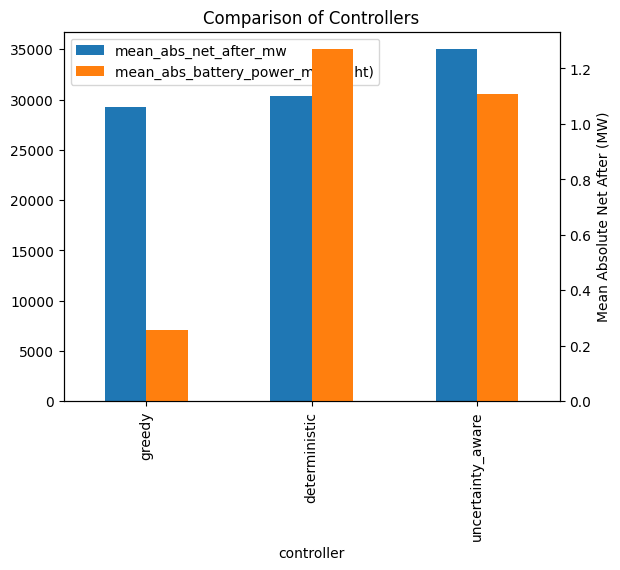

In [21]:
summary = pd.DataFrame({
    "controller": ["greedy", "deterministic", "uncertainty_aware"],
    "mean_abs_net_after_mw": [
        greedy["net_after"].abs().mean(),
        det["net_after"].abs().mean(),
        ua["net_after"].abs().mean(),
    ],
    "mean_abs_battery_power_mw": [
        greedy["power"].abs().mean(),
        det["power"].abs().mean(),
        ua["power"].abs().mean(),
    ]
})

summary.plot(x="controller", y=["mean_abs_net_after_mw", "mean_abs_battery_power_mw"], kind="bar", secondary_y="mean_abs_battery_power_mw")
plt.title("Comparison of Controllers")
plt.ylabel("Mean Absolute Net After (MW)")
plt.show()

## The table above is the first important result.

### All three controllers use:

- the same data,
- the same battery,
- and the same simulation structure.

So any difference comes from **decision quality**, not from changing the hardware.

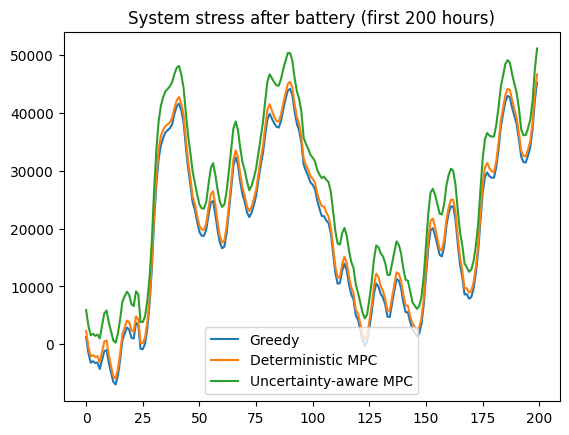

In [22]:
window = slice(0, 200)

plt.figure()
plt.plot(greedy["net_after"][window], label="Greedy")
plt.plot(det["net_after"][window], label="Deterministic MPC")
plt.plot(ua["net_after"][window], label="Uncertainty-aware MPC")
plt.legend()
plt.title("System stress after battery (first 200 hours)")
plt.show()

## Main visual result

This plot compares the remaining system stress after battery action.

Interpretation:

- **Greedy** reacts only to the current hour
- **Deterministic MPC** looks ahead
- **Uncertainty-aware MPC** looks ahead and also accounts for forecast risk

This is the core comparison of the project.

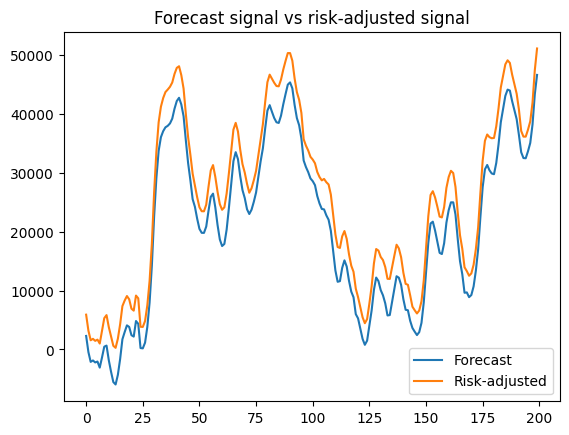

In [23]:
plt.figure()
plt.plot(ua["forecast_net_load_mw"][window], label="Forecast")
plt.plot(ua["risk_adjusted_net_load_mw"][window], label="Risk-adjusted")
plt.legend()
plt.title("Forecast signal vs risk-adjusted signal")
plt.show()

## What uncertainty changes

- The uncertainty-aware controller does not optimize only the forecasted signal.

- Instead, it optimizes a **risk-adjusted** signal:

    - forecast net load
    - plus a reserve margin derived from the uncertainty analysis

- This means the controller becomes more cautious in hours where forecast uncertainty is historically larger.

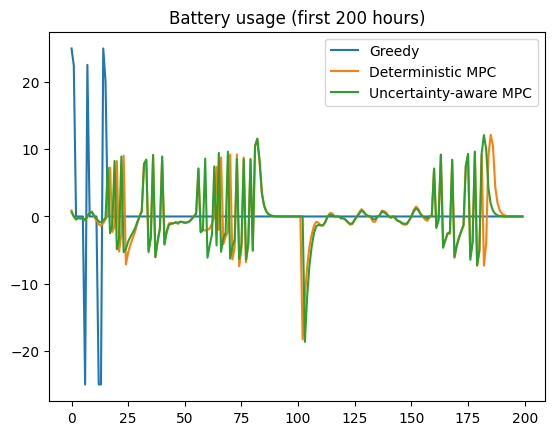

In [24]:
plt.figure()
plt.plot(greedy["power"][window], label="Greedy")
plt.plot(det["power"][window], label="Deterministic MPC")
plt.plot(ua["power"][window], label="Uncertainty-aware MPC")
plt.legend()
plt.title("Battery usage (first 200 hours)")
plt.show()

## Battery behavior

- This plot shows how each controller uses the battery.

- This is important because a controller should not only reduce stress, but also do so through clear and meaningful actions.
- Here we can see the difference between:

    - reactive behavior,
    - predictive behavior,
    - and uncertainty-aware predictive behavior.

## What we learned

### Phase 4 showed that:

- moving from heuristics to MPC changes the project from rule-based control to optimization-based control,
- the objective function strongly shapes controller behavior,
- uncertainty information can be inserted directly into the control signal,
- and better future modeling leads to different decisions even with the same battery and the same data.
- Formal optimization changes the project from heuristic control to predictive control.
- MPC behavior depends strongly on the objective, not only on the solver.
- A small actuator is a good test of controller intelligence, because it cannot hide weak decision logic behind large capacity.
- Deterministic MPC is already more principled than heuristic control, but it still ignores forecast risk.
- Uncertainty-aware MPC is a more appropriate controller for this project, because it uses the uncertainty information built in Phase 2.